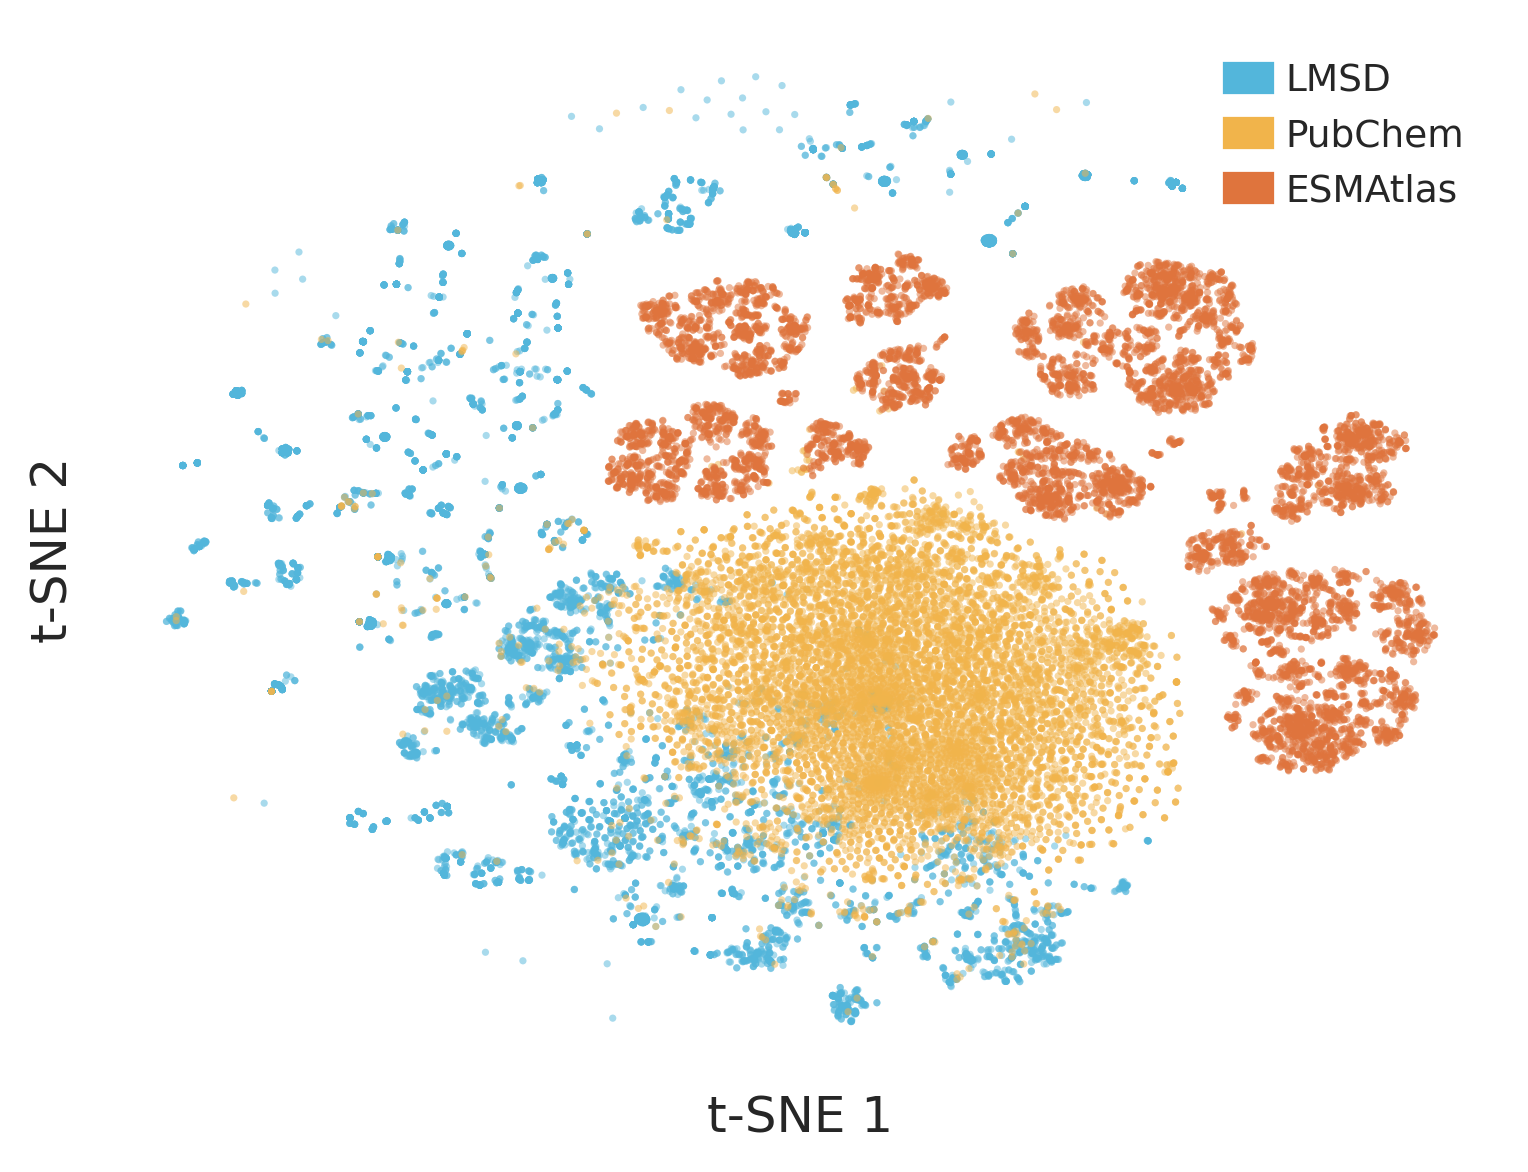

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# Load data
tsne_df = pd.read_csv("figure_data/fig2A_pretraining_data_mfp_tsne.csv")

# Style setup
sns.set_theme(style="white", context="talk")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
    "axes.linewidth": 0.8,
    "axes.edgecolor": "0.2",
    "xtick.direction": "out",
    "ytick.direction": "out",
})

# Plot
fig, ax = plt.subplots(figsize=(6, 4.5), dpi=300)

# make colormap
palette = sns.color_palette("Set2", desat=0.8)
colormap = palette.as_hex()[0:3]
colormap = ['#6abcdb', '#edbb64', '#dc8356']

# make colors brighter add brightness function
def brighten_color(color, factor=0):
    color = mpl.colors.to_rgb(color)
    brightened = tuple(min(1, c + factor) for c in color)
    return brightened

for i in range(len(colormap)):
    colormap[i] = brighten_color(colormap[i], factor=-0.05)

# desat colors
def desat_color(color, factor=0.5):
    color = mpl.colors.to_rgb(color)
    desaturated = tuple(c * factor + (1 - factor) * 0.5 for c in color)
    return desaturated

for i in range(len(colormap)):
    colormap[i] = desat_color(colormap[i], factor=1.1)

# make more vibrant
def saturate_color(color, factor=1.2):
    color = mpl.colors.to_rgb(color)
    gray = sum(color) / 3
    saturated = tuple(
        max(0, min(1, gray + (c - gray) * factor)) for c in color
    )
    return saturated

for i in range(len(colormap)):
    colormap[i] = saturate_color(colormap[i], factor=1.1)

# print colormap as hex
for i in range(len(colormap)):
    colormap[i] = mpl.colors.to_hex(colormap[i])
# print(colormap)

scatter = ax.scatter(
    tsne_df["t-SNE1"],
    tsne_df["t-SNE2"],
    c=tsne_df["source"].map({k: v for v, k in enumerate(tsne_df["source"].unique())}),
    cmap=mpl.colors.ListedColormap(colormap),
    s=3,
    alpha=0.5,
    edgecolors="none"
)

# build legend with color patches
handles = [
    mpl.patches.Patch(color=colormap[i], label=label)
    for i, label in enumerate(tsne_df["source"].unique())
]
ax.legend(
    handles=handles,
    title=None,
    loc="upper right",
    frameon=False,
    fontsize=9,
    handlelength=1.2,
    handletextpad=0.4,
)

ax.set_xlabel("t-SNE 1", fontsize=12, labelpad=6)
ax.set_ylabel("t-SNE 2", fontsize=12, labelpad=6)
ax.set_xticks([])
ax.set_yticks([])
sns.despine(ax=ax, left=True, bottom=True)

plt.savefig("figures/fig2A_pretraining_data.svg", bbox_inches="tight", dpi=300)
plt.savefig("figures/fig2A_pretraining_data.pdf", bbox_inches="tight", dpi=300)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np

# Reset params
plt.rcParams.update(plt.rcParamsDefault)

# --- Load datasets ---
ea_lengths_df = pd.read_csv('figure_data/fig2B_token_lengths_ESM_Atlas.csv')
pc_lengths_df = pd.read_csv('figure_data/fig2B_token_lengths_PubChem.csv')

# --- Extract columns ---
ea_a_lengths = ea_lengths_df['Atomistic_Length'].dropna().tolist()
ea_k_lengths = ea_lengths_df['Kmer_Length'].dropna().tolist()

pc_a_lengths = pc_lengths_df['Atomistic_Length'].dropna().tolist()
pc_k_lengths = pc_lengths_df['Kmer_Length'].dropna().tolist()

# --- Define colors ---
colors = {
    "kmer": "#feb23f",   
    "atom": "#61bdcd" # muted blue # "#C791D4",
}

# --- Create vertically stacked subplots ---
fig, axes = plt.subplots(2, 1, figsize=(5, 5), sharex=False, dpi=300)

for ax in axes:
    ax.yaxis.set_ticks_position('none')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# --- Helper function for KDE ---
def plot_kde(ax, data, color, label, xlim):
    data = np.array(data)
    kde = gaussian_kde(data, bw_method=0.3)
    xs = np.linspace(0, xlim, 500)
    ax.plot(xs, kde(xs), color=color, lw=1.8, label=label)
    ax.fill_between(xs, kde(xs), color=color, alpha=0.25)

# --- PubChem plot ---
plot_kde(axes[0], pc_a_lengths, colors["atom"], "Atomistic Tokenizer", 100)
plot_kde(axes[0], pc_k_lengths, colors["kmer"], "K-mer Tokenizer", 100)
axes[0].set_xlim(0, 100)
axes[0].legend()
axes[0].set_ylabel('Density')
axes[0].set_title('PubChem')

# --- ESMAtlas plot ---
plot_kde(axes[1], ea_a_lengths, colors["atom"], "Atomistic Tokenizer", 1600)
plot_kde(axes[1], ea_k_lengths, colors["kmer"], "K-mer Tokenizer", 1600)
axes[1].set_xlim(0, 1600)
axes[1].set_ylabel('Density')
axes[1].set_xlabel('Length of Tokenized SMILES strings')
axes[1].set_title('ESMAtlas')

plt.tight_layout()

plt.savefig("figures/fig2BC_pretraining_data.svg", bbox_inches="tight", dpi=300)
plt.savefig("figures/fig2BC_pretraining_data.pdf", bbox_inches="tight", dpi=300)
# plt.show()

# --- Compute averages & compression ratios ---
def summarize(name, a_lengths, k_lengths):
    avg_a = sum(a_lengths) / len(a_lengths) if a_lengths else 0
    avg_k = sum(k_lengths) / len(k_lengths) if k_lengths else 0
    ratio = avg_k / avg_a if avg_a else float('inf')
    print(f"{name}:")
    print(f"  Avg Atomistic: {avg_a:.2f}")
    print(f"  Avg K-mer: {avg_k:.2f}")
    print(f"  Compression Ratio (K/A): {ratio:.2f}")
    print("-" * 40)

summarize("ESMAtlas", ea_a_lengths, ea_k_lengths)
summarize("PubChem", pc_a_lengths, pc_k_lengths)

ESMAtlas:
  Avg Atomistic: 860.39
  Avg K-mer: 312.24
  Compression Ratio (K/A): 0.36
----------------------------------------
PubChem:
  Avg Atomistic: 36.08
  Avg K-mer: 22.43
  Compression Ratio (K/A): 0.62
----------------------------------------


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Pretraining results ---
pre_df = pd.DataFrame([
    ["32M", "MLM", 0.13],
    ["32M", "MLM-MTR", 0.23],
    ["32M", "MTR", 0.38],
    ["114M", "MLM", 0.47],
    ["114M", "MTR", 0.50],
    ["114M", "MLM-MTR", 0.52],
    ["337M", "MLM", 0.58],
    ["337M", "MLM-MTR", 0.58],
    ["337M", "MTR", 0.58],
], columns=["Model", "Training_method", "R2"])

# --- Finetuning results (best layer) ---
df = pd.read_csv("figure_data/fig3D_lasso_predictions.csv")
best_df = (
    df.groupby(["Model", "Training_method"], as_index=False)
      .agg({"R2": "max"})
)
best_df["Model"] = best_df["Model"].map({"small": "32M", "base": "114M", "large": "337M"})
best_df["Training_method"] = best_df["Training_method"].map({
    "MLM_only": "MLM", 
    "MTR_only": "MTR", 
    "MLM-MTR": "MLM-MTR"
})

# sort best_df by Model size
model_size_order = {"32M": 0, "114M": 1, "337M": 2}
best_df["Model_sort"] = best_df["Model"].map(model_size_order)
best_df = best_df.sort_values(by=["Model_sort", "Training_method"]).drop(columns=["Model_sort"])

# --- Setup ---
sns.set_theme(style="white", context="talk")
test = ["#798234","#a3ad62","#d0d3a2","#fdfbe4","#f0c6c3","#df91a3","#d46780"]

palette = {
    "MLM": "#d8ac34",      # Steel blue
    "MLM-MTR": "#e17966",  # Seafoam
    "MTR": "#aa6889"       # Muted rose
}

model_order = ["32M", "114M", "337M"]
train_order = ["MLM", "MLM-MTR", "MTR"]

# --- Dual Figure ---
# make single plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4), dpi=300)

# make axis lines thinner
for ax in [ax1, ax2]:
    ax.spines['top'].set_linewidth(1)
    ax.spines['right'].set_linewidth(1)
    ax.spines['left'].set_linewidth(1)
    ax.spines['bottom'].set_linewidth(1)

# change tick fontsize
ax1.tick_params(axis='x', labelsize=10)
ax1.tick_params(axis='y', labelsize=10)
ax2.tick_params(axis='x', labelsize=10)
ax2.tick_params(axis='y', labelsize=10)

# --- Panel A: transfer learning ---
sns.lineplot(
    data=best_df,
    x="Model", y="R2",
    hue="Training_method",
    hue_order=train_order,
    palette=palette,
    marker="o", markersize=7,
    linewidth=3,
    linestyle="--",
    ax=ax1,
    legend=False,
)
ax1.axhline(0.303, color="#6C6C6C", linestyle="--", lw=1.5)
ax1.axhline(0.196, color="#C1C1C1", linestyle="--", lw=1.5)
ax1.set_title("Transfer Learning", loc="center", fontsize=12)
ax1.set_xlabel("Model Size", fontsize=12)
ax1.set_ylabel(r"$R^2$ on Permeability", fontsize=12)
ax1.set_ylim(0, 0.65)
sns.despine(ax=ax1)

# --- Panel B: Finetuning ---
sns.lineplot(
    data=pre_df,
    x="Model", y="R2",
    hue="Training_method",
    hue_order=train_order,
    palette=palette,
    marker="o", markersize=7,
    linewidth=3,
    linestyle="-",
    ax=ax2,
    legend=False,
)
morgan_fp_line = ax2.axhline(0.303, color="#6C6C6C", linestyle="--", lw=1.5, label="MorganFP")
rdkit99_line   = ax2.axhline(0.196, color="#C1C1C1", linestyle="--", lw=1.5, label="RDKit99")
ax2.set_title("Finetuning", loc="center", fontsize=12)
ax2.set_xlabel("Model Size", fontsize=12)
# ax2.set_ylabel(r"$R^2$ on Permeability", fontsize=12)
ax2.set_ylabel(None)
ax2.set_ylim(0, 0.65)
sns.despine(ax=ax2)

# --- Unified Legend ---
legend_handles = [
    plt.Line2D([0], [0], color=palette["MTR"], lw=2, marker="o", label="MTR"),
    plt.Line2D([0], [0], color=palette["MLM-MTR"], lw=2, marker="o", label="MLM-MTR"),
    plt.Line2D([0], [0], color=palette["MLM"], lw=2, marker="o", label="MLM"),
    plt.Line2D([0], [0], color="#6C6C6C", lw=1.5, linestyle="--", label="MorganFP"),
    plt.Line2D([0], [0], color="#C1C1C1", lw=1.5, linestyle="--", label="RDKit99"),
]

fig.legend(
    handles=legend_handles,
    title=None,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.4, 0.9),
    ncol=1,
    fontsize=10,
)

plt.tight_layout()
plt.subplots_adjust(top=0.9, hspace=0.25)
plt.savefig("figures/fig3DE_membrane_permeation.svg", bbox_inches="tight")
plt.savefig("figures/fig3DE_membrane_permeation.pdf", bbox_inches="tight")


In [ ]:
import numpy as np
import pandas as pd
import plotnine as p9
from plotnine import (
    ggplot,
    aes,
    geom_violin,
    geom_sina,
    geom_hline,
    scale_fill_manual,
    scale_color_manual,
    labs,
    theme_classic,
    theme
)

# Sample Data Creation (Replace this with actual data loading)
df = pd.read_csv('figure_data/fig3D_lasso_predictions.csv')

# sort by Model (small, base, large)
df['Model'] = pd.Categorical(
    df['Model'], 
    categories=['small', 'base', 'large'], 
    ordered=True
)

# 2. Define Custom Colors
# We need three colors for the fill (lighter) and three for the outline (darker)
outline_colors = [
    "#d8ac34", 
    "#e17966", 
    "#aa6889"
    ] # Darker shades for outline/sina points

fill_colors = [
    "#F5D273", 
    "#F79B8B", 
    "#D696B6"
    ] # Light shades for fill

# Combine colors into a single dictionary for easier mapping (optional, but clean)
color_map = {
    'MLM_only': {'fill': fill_colors[0], 'outline': outline_colors[0]},
    'MLM-MTR': {'fill': fill_colors[1], 'outline': outline_colors[1]},
    'MTR_only': {'fill': fill_colors[2], 'outline': outline_colors[2]}
}

# Extract lists for plotnine
fill_list = [v['fill'] for v in color_map.values()]
outline_list = [v['outline'] for v in color_map.values()]

# 3. Create the Plot
plot = (
    ggplot(df, aes(x='Model', y='R2', fill='Training_method', color='Training_method'))
    # MFP Benchmark Line (0.393, Red Dashed)
    + geom_hline(
        yintercept=0.303,
        linetype='dashed',
        size=1,
        color='#6C6C6C'  # Explicitly set to red
    )
    # RDKit99 Benchmark Line (0.196, Black Dashed)
    + geom_hline(
        yintercept=0.196,
        linetype='dashed',
        size=1,
        color='#C1c1c1' # Explicitly set to black
    )
    + geom_violin(
        # The outline border color of the violin
        aes(fill='Training_method', color='Training_method'),
        style='full',
        size=0.8,
        show_legend=True
    )
    + geom_sina(
        aes(color='Training_method'),
        # remove last layer points
        data=df[df['Layer'] != df.groupby(['Model', 'Training_method'])['Layer'].transform('max')],
        # fill points for the sina plot should be solid outline_colors
        size=2,
        alpha=1,
        show_legend=False,
        # fill cannot just be set to outline_colors here, must be mapped via aes()
    )
    # add a black dot for the last layer of each model and training method
    + geom_sina(
        data=df.groupby(['Model', 'Training_method']).apply(lambda x: x.nlargest(1, 'Layer')).reset_index(drop=True),
        mapping=aes(x='Model', y='R2'),
        color='black',
        size=2.5,
        alpha=1,
        show_legend=False,
    )
    
    # Custom color scales for Fill and Outline/Sina
    + scale_fill_manual(values=fill_list)
    + scale_color_manual(values=outline_list)
    # make x-ticks font larger
    
    # Labels and Theme
    + labs(
        title='',
        y='R2 Metric',
        x=''
    )
    
    # add plot size
    + theme_classic()
)

# 4. Display/Save the Plot
plot = plot+theme(
    legend_position=(0.9, 0.1),
    axis_text_x=p9.element_text(size=12, color='black'),
    # change Training_method legend title to 'Training Method'
    legend_title=p9.element_text(text='Training Method'),
    )
plot.save('figures/figS3_LassoCV_Sina_plot.svg', width=8/1.5, height=6/1.5, dpi=300) # Uncomment to save
plot.save('figures/figS3_LassoCV_Sina_plot.pdf', width=8/1.5, height=6/1.5, dpi=300) # Uncomment to save


/tmp/ipykernel_3674586/1147290310.py:79: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/tmp/ipykernel_3674586/1147290310.py:88: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/tmp/ipykernel_3674586/1147290310.py:88: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/stor/work/Wilke/afeller/PeptideMTR_final_pub/PeptideMTR/.venv/lib/pyth

In [5]:
import pandas as pd
import plotnine as p9

# ---- Data ----
data = [
    [32, "Kmer", "Span", "Yes", "No", 0.13, 0.72, 0.68, 0.69],
    [32, "Kmer", "Span", "Yes", "Yes", 0.23, 0.68, 0.70, 0.74],
    [32, "Kmer", "None", "No", "Yes", 0.38, 0.61, 0.76, 0.73],
    [114, "Kmer", "Span", "Yes", "No", 0.47, 0.56, 0.80, 0.77],
    [114, "Kmer", "None", "No", "Yes", 0.50, 0.55, 0.80, 0.78],
    [114, "Kmer", "Span", "Yes", "Yes", 0.52, 0.54, 0.81, 0.78],
    [337, "Kmer", "Span", "Yes", "No", 0.58, 0.50, 0.83, 0.81],
    [337, "Kmer", "Span", "Yes", "Yes", 0.58, 0.50, 0.83, 0.81],
    [337, "Kmer", "None", "No", "Yes", 0.58, 0.50, 0.83, 0.81],
    # Note: Params are integers here (0 and 1)
    [0, "Morgan FP", "N/A", "N/A", "N/A", 0.303, None, None, None],
    [1, "RDKit99", "N/A", "N/A", "N/A", 0.196, None, None, None],
]

df = pd.DataFrame(
    data, columns=["Params", "Tokenizer", "Masking", "MLM", "MTR", "R2", "RMSE", "ROC-AUC", "PR-AUC"]
)

# ---- 1. Label Construction ----
def build_label(row):
    # FIXED: Check for the Integer values 0 and 1, not the string names
    if row["Params"] == 0:
        return "Morgan FP"
    elif row["Params"] == 1:
        return "RDKit99"

    # Standard logic for models
    tokenizer = row["Tokenizer"]
    masking = row["Masking"] + " Masking"
    if masking == "None Masking": masking = "No Masking"
    elif masking == "* Masking": masking = "N/A"

    if row["MLM"] == "Yes" and row["MTR"] == "Yes": pretraining = "MLM-MTR"
    elif row["MLM"] == "Yes": pretraining = "MLM"
    elif row["MTR"] == "Yes": pretraining = "MTR"
    else: pretraining = "Random Init"

    model_size = ""
    if row["Params"] == 32: model_size = "Small"
    elif row["Params"] == 114: model_size = "Base"
    elif row["Params"] == 337: model_size = "Large"
        
    return f"{model_size} | {pretraining}"

df["Label"] = df.apply(build_label, axis=1)

# Map Params to clean Category names
size_map = {32: "Small (32 M)", 114: "Base (114 M)", 337: "Large (337 M)", 0: "Morgan FP", 1: "RDKit99"}
df['Model_Size'] = df['Params'].map(size_map)

# Set order: Baselines at bottom, then Small -> Large
df['Model_Size'] = pd.Categorical(
    df['Model_Size'], 
    categories=["RDKit99", "Morgan FP", "Small (32 M)", "Base (114 M)", "Large (337 M)"], 
    ordered=True
)

# ---- 2. Handling Sort Order ----
# Sort by Model_Size first, then R2
df = df.sort_values(by=['R2', 'Model_Size'], ascending=[True, True]).reset_index(drop=True)
# Lock in the order for the plot
df['Label'] = pd.Categorical(df['Label'], categories=df['Label'].unique(), ordered=True)

fill_colors = [
    "#CCCCCC",
    "#CCCCCC",
    "#D4E6BD", 
    "#dfd48a", 
    "#ddad9f",
    ] # Light shades for fill

outline_colors = [
    "#999999",
    "#999999",
    "#94BB5F", 
    "#b3a33c", 
    "#bb745e",
    ] # Darker shades for outline

# ---- 3. Plotting ----
p = (
    # FIXED: Added 'fill' to aesthetics so we can use scale_fill_manual
    p9.ggplot(df, p9.aes(x='Label', y='R2', fill='Model_Size', color='Model_Size'))
    
    + p9.geom_col(width=0.8, alpha=0.9, size=1)

    + p9.geom_text(
        p9.aes(label=df['R2']),
        nudge_y=0.03,
        color='black',
        size=9, 
        format_string='{:.3f}'
    )
    # FIXED: Use scale_fill_manual instead of inline mapping
    + p9.scale_fill_manual(values=fill_colors)
    + p9.scale_color_manual(values=outline_colors)
    
    + p9.coord_flip()
    
    + p9.scale_y_continuous(limits=(0, 0.65), breaks=[0, 0.2, 0.4, 0.6])
    
    + p9.labs(y="R² Score", x="", title="")
    + p9.theme_classic()
    + p9.theme(
        figure_size=(8, 6),
        axis_text_y=p9.element_text(size=10, color="black"),
        axis_text_x=p9.element_text(size=10, color="black"),
        legend_position="right", # Keep legend to identify sizes
        legend_title=p9.element_blank(),
        panel_grid_major_x=p9.element_line(color="lightgray"),
        panel_grid_major_y=p9.element_blank(),
    )
)

# 4. Display/Save the Plot
p.save('figures/.unused_MPDB_R2_barplot.svg', dpi=300) # Uncomment to save
p.save('figures/.unused_MPDB_R2_barplot.pdf', dpi=300) # Uncomment to save

/stor/work/Wilke/afeller/PeptideMTR_final_pub/PeptideMTR/.venv/lib/python3.10/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
/stor/work/Wilke/afeller/PeptideMTR_final_pub/PeptideMTR/.venv/lib/python3.10/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/.unused_MPDB_R2_barplot.svg
/stor/work/Wilke/afeller/PeptideMTR_final_pub/PeptideMTR/.venv/lib/python3.10/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
/stor/work/Wilke/afeller/PeptideMTR_final_pub/PeptideMTR/.venv/lib/python3.10/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/.unused_MPDB_R2_barplot.pdf


In [6]:
import pandas as pd
import plotnine as p9
import warnings

# ---- 1. Data Preparation: Combine and Format ----

# Define the column names for the raw data
cols = ["Dataset", "Target", "Prior", "FPs", "MLM", "MLM-MTR", "MTR"]

# Original Color Definitions
# Note: The original color lists defined 4 colors, but only 3 ML models are being compared
# We will use the colors corresponding to MLM, MLM-MTR, and MTR (indices 1, 2, 3)

outline_colors_full = [
    "#999999", # Prior (Index 0)
    "#d8ac34", # MLM (Index 1)
    "#e17966", # MLM-MTR (Index 2)
    "#aa6889"  # MTR (Index 3)
] 

fill_colors_full = [
    "#CCCCCC", # Prior (Index 0)
    "#F5D273", # MLM (Index 1)
    "#F79B8B", # MLM-MTR (Index 2)
    "#D696B6"  # MTR (Index 3)
] 

# Create Finetuning DataFrame
df_ft = pd.DataFrame([
    ["THPep", "Tumor Homing (MCC)", 0.71, 0.478, 0.732, 0.698, 0.680],
    ["CellPPD-Mod", "Cell Penetrating (MCC)", 0.85, 0.772, 0.868, 0.875, 0.856],
    ["AMP-HGT", "Antimicrobial (MCC)", 0.797, 0.813, 0.813, 0.771, 0.735],
    # ["MHC-I", "MHC Binding ($R^2$)", 0.477, 0.446, 0.659, 0.524]
], columns=cols)
df_ft['Strategy'] = 'Finetuning'

# Create Transfer Learning DataFrame
df_tl = pd.DataFrame([
    ["THPep", "Tumor Homing (MCC)", 0.71, 0.478, 0.602, 0.637, 0.638],
    ["CellPPD-Mod", "Cell Penetrating (MCC)", 0.85, 0.772, 0.755, 0.781, 0.781],
    ["AMP-HGT", "Antimicrobial (MCC)", 0.797, 0.813, 0.662, 0.618, 0.489],
    # ["MHC-I", "MHC Binding ($R^2$)", 0.477, 0.499, 0.437, 0.441]
], columns=cols)
df_tl['Strategy'] = 'Transfer Learning'

# Combine the dataframes
df_combined = pd.concat([df_ft, df_tl], ignore_index=True)

# Melt to long format for ggplot/plotnine, focusing only on the three ML Models
df_long = df_combined.melt(
    id_vars=["Dataset", "Target", "Strategy"], 
    value_vars=["MLM", "MLM-MTR", "MTR"], 
    var_name="Model", 
    value_name="Score"
)

# Define Model Order
model_order = ["MLM", "MLM-MTR", "MTR"]
df_long['Model'] = pd.Categorical(df_long['Model'], categories=model_order, ordered=True)

# Define Model Colors (extracting relevant colors)
model_fill_colors = dict(zip(model_order, fill_colors_full[1:]))
model_outline_colors = dict(zip(model_order, outline_colors_full[1:]))

# Strategy Alpha/Linetype mapping
strategy_alpha = {
    'Finetuning': 1.0, # Solid fill
    'Transfer Learning': 0.6 # Lighter fill
}

# The dodge width for positioning
dodge_width = 0.8 

# --- 2. Plotting ---

# Get the list of unique target tasks
unique_targets = df_long['Target'].unique()

for target in unique_targets:
    # Filter the data for the current target task
    df_filtered = df_long[df_long['Target'] == target]
    
    # Extract the base metric (MCC or R^2) for the Y-axis label
    metric = target.split('(')[1].replace(')', '')
    dataset_name = target.split('(')[0].strip()

# Define Model Order (as before)
model_order = ["MLM", "MLM-MTR", "MTR"]
# Convert Model to a numerical factor (1, 2, 3)
df_long['Model_Num'] = df_long['Model'].cat.codes + 1 

# Define Strategy Order and Offsets (This determines the shift)
# Strategy 1 (Finetuning) will be shifted left (-offset)
# Strategy 2 (Transfer Learning) will be shifted right (+offset)
strategy_order = ['Transfer Learning', 'Finetuning']
# Calculate the half-width offset based on the dodge_width (0.8)
# We want the offset to be half of the difference between dodge_width and 1.0 (the full category width)
# A simpler way is to use half the bar width or the dodge_width adjusted for the number of groups.
# Since you have 2 strategies, the offset is approximately 1/2 of the dodge_width.
half_dodge = dodge_width / (len(strategy_order) * 2) # 0.8 / 4 = 0.2

# Define the shift for each strategy
strategy_shift = {
    'Finetuning': -half_dodge, # e.g., -0.2
    'Transfer Learning': half_dodge # e.g., +0.2
}

# Apply the shift to create the precise x-coordinate for text labels
df_long['Strategy_Shift'] = df_long['Strategy'].map(strategy_shift)
df_long['x_position'] = df_long['Model_Num'] + df_long['Strategy_Shift']


# --- 2. Plotting (Modified Snippet) ---

# Get the list of unique target tasks
unique_targets = df_long['Target'].unique()

# --- 1. Data Preparation (Continuation): Re-calculating X-positions ---

# Define Strategy Order (This is the new X-axis)
strategy_order = ['Transfer Learning', 'Finetuning']
df_long['Strategy'] = pd.Categorical(df_long['Strategy'], categories=strategy_order, ordered=True)
df_long['Strategy_Num'] = df_long['Strategy'].cat.codes + 1 

# Define Model Order (This is the new dodge/group)
model_order = ["MLM", "MLM-MTR", "MTR"]
df_long['Model'] = pd.Categorical(df_long['Model'], categories=model_order, ordered=True)
model_codes = df_long['Model'].cat.codes # codes are 0, 1, 2

# We have 3 models being dodged (num_groups=3)
num_groups = len(model_order) 
# Calculate the position shift for each model (0, 1, 2)
# This calculation ensures the three dodged bars are centered on the Strategy's category tick mark.
group_positions = (model_codes - (num_groups - 1) / 2) * dodge_width / num_groups
# Example group_positions: approx. -0.266, 0.0, 0.266 (for dodge_width=0.8, 3 groups)

# Apply the shift to create the precise x-coordinate for text labels
df_long['x_model_shift'] = group_positions
df_long['x_position'] = df_long['Strategy_Num'] + df_long['x_model_shift']

# --- 2. Plotting (Updated Loop) ---

# Get the list of unique target tasks
unique_targets = df_long['Target'].unique()

for i, target in enumerate(unique_targets):
    # Filter the data for the current target task
    df_filtered = df_long[df_long['Target'] == target].copy() 
    
    # Extract the base metric (MCC or R^2) for the Y-axis label
    metric = target.split('(')[1].replace(')', '')
    dataset_name = target.split('(')[0].strip()

    # Retrieve Prior and FPs scores (needs to be done from the original combined dataframe)
    prior_score = df_ft[df_ft['Target'] == target]['Prior'].values[0]
    fps_score = df_ft[df_ft['Target'] == target]['FPs'].values[0]

    p = (
        # Main ggplot: X is Strategy, Fill/Color/Group are Model
        p9.ggplot(
            df_filtered, 
            p9.aes(x='Strategy', y='Score', fill='Model', color='Model', group='Model')
        )
        
        # 0. Horizontal Lines
        + p9.geom_hline(
            yintercept=prior_score,
            linetype='dashed',
            size=1,
            color='#6C6C6C' # Prior
        )
        + p9.geom_hline(
            yintercept=fps_score,
            linetype='dashed',
            size=1,
            color='red' # FPs
        )


        # 1. Bar Chart: White background to hide lines (Alpha = 1, Fill = 'white')
        + p9.geom_col(
            # CRITICAL: Manually map X, Y, and the dodging group (Model)
            p9.aes(x='Strategy', y='Score', group='Model'), 
            inherit_aes=False,  
            position=p9.position_dodge(width=dodge_width),
            width=0.7, 
            size=1,
            fill='white', # Explicitly set fill color
            color='white', # Explicitly set outline color
            alpha=1        # Explicitly set alpha
        )

        # 2. Bar Chart: Colored, with Strategy alpha 
        + p9.geom_col(
            p9.aes(alpha='Strategy'), # Uses fill='Model', color='Model' from main p9.ggplot()
            position=p9.position_dodge(width=dodge_width),
            width=0.7, 
            size=1,
        )
        
        # 3. Text Labels: Using the pre-calculated numerical x_position
        + p9.geom_text(
            p9.aes(x='x_position', label='Score', group='Model'),
            va='bottom', 
            size=11, 
            color='black',
            format_string='{:.3f}', 
            nudge_y=-0.065
        )
        
        # 4. Custom Colors for Models (Fill and Outline)
        + p9.scale_fill_manual(values=model_fill_colors)
        + p9.scale_color_manual(values=model_outline_colors)
        
        # 5. Custom Alpha for Strategies
        + p9.scale_alpha_manual(values=strategy_alpha)
        
        # 6. Labels and Theme
        + p9.labs(
            x="", 
            y=f"{metric}", 
            title=""
        )
        + p9.theme_classic()
        + p9.theme(
            figure_size=(6, 4),
            axis_text_x=p9.element_text(rotation=0, hjust=0.5, size=12, color="black"),
            axis_text_y=p9.element_text(size=12, color="black"),
            title=p9.element_text(size=12),
            panel_spacing=0.05
        )
        # 7. Add a little headroom for the text labels
        + p9.scale_y_continuous(expand=(0, 0, 0.15, 0))

        # 8. Use scale_x_discrete to ensure categorical labels remain, 
        # mapping the Strategy order
        + p9.scale_x_discrete(
            breaks=strategy_order, 
            labels=strategy_order
        )

        # 9. remove the legend
        + p9.theme(legend_position='none')
    )
    
    plt = p

    # fignames are B D F instead of i
    fig_labels = ['B', 'D', 'F']

    # Save the plot
    plt.save(f'figures/fig4{fig_labels[i]}_{dataset_name.replace(" ", "_")}_barplot.svg', dpi=300)
    plt.save(f'figures/fig4{fig_labels[i]}_{dataset_name.replace(" ", "_")}_barplot.pdf', dpi=300)

    # plt.show()

/stor/work/Wilke/afeller/PeptideMTR_final_pub/PeptideMTR/.venv/lib/python3.10/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6 x 4 in image.
/stor/work/Wilke/afeller/PeptideMTR_final_pub/PeptideMTR/.venv/lib/python3.10/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/fig4B_Tumor_Homing_barplot.svg
/stor/work/Wilke/afeller/PeptideMTR_final_pub/PeptideMTR/.venv/lib/python3.10/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6 x 4 in image.
/stor/work/Wilke/afeller/PeptideMTR_final_pub/PeptideMTR/.venv/lib/python3.10/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/fig4B_Tumor_Homing_barplot.pdf
/stor/work/Wilke/afeller/PeptideMTR_final_pub/PeptideMTR/.venv/lib/python3.10/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6 x 4 in image.
/stor/work/Wilke/afeller/PeptideMTR_final_pub/PeptideMTR/.venv/lib/python3.10/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/fig4D_Cell_Penetr

In [7]:
# # Generate token embeddings from the model(s)
# import pandas as pd
# import numpy as np

# # load model from huggingface
# from transformers import AutoModel, AutoTokenizer
# model_name = "aaronfeller/PeptideMLM-MTR_lg"

# tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
# model = AutoModel.from_pretrained(model_name, trust_remote_code=True)

# # import CycPeptMPDB data
# df = pd.read_csv('../notebooks/PAMPA_clustered.csv')


In [8]:
# import torch
# from tqdm import tqdm

# # generate embeddings for all sequences in the dataframe
# embeddings = []
# smiles = df['SMILES'].tolist()
# batch_size = 64

# # model and data to device
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# model.to(device)

# for i in tqdm(range(0, len(smiles), batch_size)):
#     batch_smiles = smiles[i:i+batch_size]
#     inputs = tokenizer(batch_smiles, return_tensors="pt", padding=True, truncation=True).to(device)
#     with torch.no_grad():
#         outputs = model(**inputs)
#     # mean pool the token embeddings to get a single embedding per sequence
#     batch_embeddings = outputs['mean_pool'].cpu().numpy()
#     embeddings.extend(batch_embeddings)

# embeddings = np.array(embeddings)
# print("Embeddings shape:", embeddings.shape)

In [9]:
# # calculate logp using rdkit 
# from rdkit import Chem
# from rdkit.Chem import Crippen
# from rdkit.Chem import Descriptors

# from tqdm import tqdm

# logp_values = []
# for smi in tqdm(df['SMILES']):
#     mol = Chem.MolFromSmiles(smi)
#     logp = Crippen.MolLogP(mol)
#     logp_values.append(logp)

# df['LogP'] = logp_values

# # calculate number of atoms using rdkit
# num_atoms = []
# for smi in tqdm(df['SMILES']):
#     mol = Chem.MolFromSmiles(smi)
#     n_atoms = Descriptors.HeavyAtomCount(mol)
#     num_atoms.append(n_atoms)
# df['Num_Atoms'] = num_atoms

# MolWts = []
# for smi in tqdm(df['SMILES']):
#     mol = Chem.MolFromSmiles(smi)
#     MolWt = Descriptors.ExactMolWt(mol)
#     MolWts.append(MolWt)
# df['MolWt'] = MolWts

# maxAbsPartialCharge = []
# minAbsPartialCharge = []
# MaxPartialCharge = []
# MinPartialCharge = []

# for smi in tqdm(df['SMILES']):
#     mol = Chem.MolFromSmiles(smi)
#     Chem.rdPartialCharges.ComputeGasteigerCharges(mol)
#     charges = [float(atom.GetProp('_GasteigerCharge')) for atom in mol.GetAtoms()]
#     maxAbsPartialCharge.append(max(abs(charge) for charge in charges))
#     minAbsPartialCharge.append(min(abs(charge) for charge in charges))
#     MaxPartialCharge.append(max(charges))
#     MinPartialCharge.append(min(charges))
# df['MaxAbsPartialCharge'] = maxAbsPartialCharge
# df['MinAbsPartialCharge'] = minAbsPartialCharge
# df['MaxPartialCharge'] = MaxPartialCharge
# df['MinPartialCharge'] = MinPartialCharge

# # calculate NumRotatableBonds, NumAliphatic/AromaticRings, TPSA, Nchiral, and NumHDonors/Acceptors using rdkit
# NumRotatableBonds = []
# NumAliphaticRings = []
# NumAromaticRings = []
# TPSA = []
# Nchiral = []
# NumHDonors = []
# NumHAcceptors = []

# for smi in tqdm(df['SMILES']):
#     mol = Chem.MolFromSmiles(smi)
#     NumRotatableBonds.append(Descriptors.NumRotatableBonds(mol))
#     NumAliphaticRings.append(Descriptors.NumAliphaticRings(mol))
#     NumAromaticRings.append(Descriptors.NumAromaticRings(mol))
#     TPSA.append(Descriptors.TPSA(mol))
#     Nchiral.append(len(Chem.FindMolChiralCenters(mol, includeUnassigned=True)))
#     NumHDonors.append(Descriptors.NumHDonors(mol))
#     NumHAcceptors.append(Descriptors.NumHAcceptors(mol))
# df['NumRotatableBonds'] = NumRotatableBonds
# df['NumAliphaticRings'] = NumAliphaticRings
# df['NumAromaticRings'] = NumAromaticRings
# df['TPSA'] = TPSA
# df['Nchiral'] = Nchiral
# df['NumHDonors'] = NumHDonors
# df['NumHAcceptors'] = NumHAcceptors


In [10]:
# # use tsne to reduce the embeddings to 2D
# from sklearn.manifold import TSNE

# tsne = TSNE(n_components=2, perplexity=30, max_iter=1000)
# embeddings_2d = tsne.fit_transform(embeddings)
# print("2D Embeddings shape:", embeddings_2d.shape)
# # add the 2D embeddings to the dataframe
# df['t-SNE1'] = embeddings_2d[:, 0]
# df['t-SNE2'] = embeddings_2d[:, 1]

# # print
# print(df.head())

# # save the dataframe to a csv
# df.to_csv("PAMPA_clustered_with_embeddings.csv", index=False)


In [11]:
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap

def create_batlow_cmap(name='batlow', N=256):
    # 1. Define the RGB color stops for the cmap Batlow10
    batlow_colors = [
        "#011959",
        "#103F60",
        "#1C5A62",
        "#3C6D56",
        "#687B3E",
        "#9D892B",
        "#D29343",
        "#F8A17B",
        "#FDB7BC",
        "#FACCFA"
    ]

    # 2. Create the LinearSegmentedColormap object
    cmap = LinearSegmentedColormap.from_list(name, batlow_colors, N=N)
    
    # 3. Register the colormap with Matplotlib
    # This allows you to call it directly by name in plt.colormaps() or in plot code.
    mpl.colormaps.register(cmap=cmap, name=name, force=True)
    
    print(f"Colormap '{name}' registered successfully.")
    return cmap

# 1. Run the function to define and register the colormap:
batlow_cmap = create_batlow_cmap()


Colormap 'batlow' registered successfully.


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
# Assuming 'df' (DataFrame) is loaded elsewhere
df = pd.read_csv('figure_data/fig3ABC_PAMPA_embeddings.csv')


# --- 1. Aesthetic Setup ---
def setup_plot_aesthetics(font_family="Arial", font_size=10):
    """Sets aesthetic parameters optimized for a dense grid layout."""
    # Use 'paper' context for smaller, denser plots
    sns.set_theme(style="white", context="paper") 
    plt.rcParams.update({
        # "font.family": "sans-serif",
        # "font.sans-serif": [font_family],
        "axes.linewidth": 0.8,
        "axes.edgecolor": "0.2",
        "xtick.direction": "out",
        "ytick.direction": "out",
        "font.size": font_size
    })

# --- 2. Core Plotting Function ---
def plot_tsne_panel(ax, df, color_col, cmap=None): # cmap options: "coolwarm", "viridis", "plasma", "inferno", "magma", "cividis"
    """Generates a single t-SNE scatter plot panel with a colorbar."""
    scatter = ax.scatter(
        df["t-SNE1"],
        df["t-SNE2"],
        c=df[color_col],
        cmap=cmap,
        s=10, # Smaller points for dense view
        alpha=0.7,
        edgecolors="none"
    )

    # Labeling and Clean-up for dense panel
    ax.set_title(color_col, fontsize=18, pad=2)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("") # Remove labels to save space
    ax.set_ylabel("")
    sns.despine(ax=ax, left=True, bottom=True)
    
    return scatter

# --- 3. Generate 3x5 Multi-Panel Figure ---

plot_colorbars = [
    "MolWt", "NumAromaticRings", "PAMPA"

    # "PAMPA", "LogP", "Num_Atoms", "MolWt", 
    # "MaxAbsPartialCharge", "MinAbsPartialCharge", 
    # "MaxPartialCharge", "MinPartialCharge", 
    # "NumRotatableBonds", "NumAliphaticRings", 
    # "NumAromaticRings", "TPSA", "Nchiral", 
    # "NumHDonors", "NumHAcceptors"
]

colors = [
    'batlow',
    'batlow',
    'batlow',
]
# Set up aesthetics
setup_plot_aesthetics() 

# Create the 3x5 figure layout (15 columns wide, 9 high is a good starting size)
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=200)
axes = axes.flatten() # Flatten the 3x5 array for easy iteration


# Iterate through features and plot to each subplot
for i, col in enumerate(plot_colorbars):
    ax = axes[i]
    scatter_obj = plot_tsne_panel(
        ax, 
        df, # Assuming 'df' is available in the environment
        color_col=col,
        cmap=colors[i]
    )
    
    # Add a thin colorbar for each plot
    cbar = plt.colorbar(scatter_obj, ax=ax, fraction=0.03, pad=0.02)
    cbar.ax.tick_params(labelsize=12)
    if col in ["MolWt"]:
        cbar.ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.0f'))
    elif col in ["NumAliphaticRings"]:
        cbar.ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.1f'))
    elif col in ["MaxAbsPartialCharge"]:
        cbar.ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))

    # change facet titles

    updated_cols = {
        "MolWt": "Molecular weight",
        "NumAromaticRings": "Aromatic rings",
        "PAMPA": "PAMPA value"
    }
    col = updated_cols.get(col, col)

    ax.set_title(col, fontsize=18, pad=2)

# Adjust spacing between plots
plt.tight_layout(w_pad=1.5, h_pad=2.0)
# plt.suptitle("Exploratory t-SNE Embeddings (Colored by Physicochemical Descriptor)", fontsize=12, y=1.02)
plt.savefig("figures/fig3ABC_PAMPA_embeddings.svg", bbox_inches="tight", dpi=300)
plt.savefig("figures/fig3ABC_PAMPA_embeddings.pdf", bbox_inches="tight", dpi=300)


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv('figure_data/fig3ABC_PAMPA_embeddings.csv')

# --- 1. Aesthetic Setup ---
def setup_plot_aesthetics(font_family="Arial", font_size=10):
    """Sets aesthetic parameters optimized for a dense grid layout."""
    # Use 'paper' context for smaller, denser plots
    sns.set_theme(style="white", context="paper") 
    plt.rcParams.update({
        # "font.family": "sans-serif",
        # "font.sans-serif": [font_family],
        "axes.linewidth": 0.8,
        "axes.edgecolor": "0.2",
        "xtick.direction": "out",
        "ytick.direction": "out",
        "font.size": font_size
    })

# --- 2. Core Plotting Function ---
def plot_tsne_panel(ax, df, color_col, cmap="batlow"): # cmap options: "viridis", "plasma", "inferno", "magma", "cividis"
    """Generates a single t-SNE scatter plot panel with a colorbar."""
    scatter = ax.scatter(
        df["t-SNE1"],
        df["t-SNE2"],
        c=df[color_col],
        cmap=cmap,
        s=10, # Smaller points for dense view
        alpha=0.7,
        edgecolors="none"
    )

    # Labeling and Clean-up for dense panel
    ax.set_title(color_col, fontsize=9, pad=2)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("") # Remove labels to save space
    ax.set_ylabel("")
    sns.despine(ax=ax, left=True, bottom=True)
    
    return scatter

# --- 3. Generate 3x5 Multi-Panel Figure ---

plot_colorbars = [
    #"PAMPA", 
    "LogP", "Num_Atoms", #"MolWt", 
    "MaxAbsPartialCharge", "MinAbsPartialCharge", 
    "MaxPartialCharge", "MinPartialCharge", 
    "NumRotatableBonds", "NumAliphaticRings", 
    #"NumAromaticRings", 
    "TPSA", "Nchiral", 
    "NumHDonors", "NumHAcceptors"
]

# Set up aesthetics
setup_plot_aesthetics() 

# Create the 3x5 figure layout (15 columns wide, 9 high is a good starting size)
fig, axes = plt.subplots(3, 4, figsize=(20, 15), dpi=200)
axes = axes.flatten() # Flatten the 3x5 array for easy iteration

# Iterate through features and plot to each subplot
for i, col in enumerate(plot_colorbars):
    ax = axes[i]
    scatter_obj = plot_tsne_panel(
        ax, 
        df, # Assuming 'df' is available in the environment
        color_col=col
    )
    
    # Add a thin colorbar for each plot
    cbar = plt.colorbar(scatter_obj, ax=ax, fraction=0.04, pad=0.02)
    cbar.ax.tick_params(labelsize=8)
    cbar.ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.1f')) # Clean up tick format if needed

    ax.set_title(col, fontsize=18, pad=2)


# Adjust spacing between plots
plt.tight_layout(w_pad=1.5, h_pad=2.0)

plt.savefig("figures/figS2_PAMPA_embeddings.svg", bbox_inches="tight", dpi=300)
plt.savefig("figures/figS2_PAMPA_embeddings.pdf", bbox_inches="tight", dpi=300)

# MHC Results

In [14]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from rdkit import Chem
from rdkit.Chem import Crippen
from rdkit.Chem import Descriptors
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns


In [15]:
# from transformers import AutoModel, AutoTokenizer
# import torch

# # load model from huggingface
# def load_model(model_name="aaronfeller/PeptideMLM-MTR_lg"):
#     tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
#     model = AutoModel.from_pretrained(model_name, trust_remote_code=True)
#     return model, tokenizer

# model, tokenizer = load_model()

# def generate_embeddings(model, tokenizer, sequences, batch_size=64):
#     embeddings = []
#     device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#     model.to(device)
#     for i in tqdm(range(0, len(sequences), batch_size)):
#         batch_seq = sequences[i:i+batch_size]
#         inputs = tokenizer(batch_seq, return_tensors="pt", padding=True, truncation=True).to(device)
#         with torch.no_grad():
#             outputs = model(**inputs)
#         # mean pool the token embeddings to get a single embedding per sequence
#         batch_embeddings = outputs['mean_pool'].cpu().numpy()
#         embeddings.extend(batch_embeddings)
#     return np.array(embeddings)


In [16]:
# # calculate logp using rdkit 
# def calculate_descriptors(df, column="SMILES"):
#     logp_values = []
#     num_atoms = []
#     molwts = []
#     maxAbsPartialCharge = []
#     minAbsPartialCharge = []
#     MaxPartialCharge = []
#     MinPartialCharge = []
#     NumRotatableBonds = []
#     NumAliphaticRings = []
#     NumAromaticRings = []
#     TPSA = []
#     Nchiral = []
#     NumHDonors = []
#     NumHAcceptors = []

#     for smi in tqdm(df[column]):
#         mol = Chem.MolFromSmiles(smi)
#         logp_values.append(Crippen.MolLogP(mol))
#         num_atoms.append(Descriptors.HeavyAtomCount(mol))
#         molwts.append(Descriptors.ExactMolWt(mol))
#         Chem.rdPartialCharges.ComputeGasteigerCharges(mol)
#         charges = [float(atom.GetProp('_GasteigerCharge')) for atom in mol.GetAtoms()]
#         maxAbsPartialCharge.append(max(abs(charge) for charge in charges))
#         minAbsPartialCharge.append(min(abs(charge) for charge in charges))
#         MaxPartialCharge.append(max(charges))
#         MinPartialCharge.append(min(charges))
#         NumRotatableBonds.append(Descriptors.NumRotatableBonds(mol))
#         NumAliphaticRings.append(Descriptors.NumAliphaticRings(mol))
#         NumAromaticRings.append(Descriptors.NumAromaticRings(mol))
#         TPSA.append(Descriptors.TPSA(mol))
#         Nchiral.append(len(Chem.FindMolChiralCenters(mol, includeUnassigned=True)))
#         NumHDonors.append(Descriptors.NumHDonors(mol))
#         NumHAcceptors.append(Descriptors.NumHAcceptors(mol))

#     df['LogP'] = logp_values
#     df['Num_Atoms'] = num_atoms
#     df['MolWt'] = molwts
#     df['MaxAbsPartialCharge'] = maxAbsPartialCharge
#     df['MinAbsPartialCharge'] = minAbsPartialCharge
#     df['MaxPartialCharge'] = MaxPartialCharge
#     df['MinPartialCharge'] = MinPartialCharge
#     df['NumRotatableBonds'] = NumRotatableBonds
#     df['NumAliphaticRings'] = NumAliphaticRings
#     df['NumAromaticRings'] = NumAromaticRings
#     df['TPSA'] = TPSA
#     df['Nchiral'] = Nchiral
#     df['NumHDonors'] = NumHDonors
#     df['NumHAcceptors'] = NumHAcceptors
#     return df


In [17]:
# # use tsne to reduce the embeddings to 2D
# def reduce_embeddings_tsne(embeddings, perplexity=30, max_iter=1000):
#     tsne = TSNE(n_components=2, perplexity=perplexity, max_iter=max_iter)
#     return tsne.fit_transform(embeddings)


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
# Assuming 'df' (DataFrame) is loaded elsewhere

# --- 1. Aesthetic Setup ---
def setup_plot_aesthetics(font_family="Arial", font_size=8):
    """Sets aesthetic parameters optimized for a dense grid layout."""
    # Use 'paper' context for smaller, denser plots
    sns.set_theme(style="white", context="paper") 
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": [font_family],
        "axes.linewidth": 0.8,
        "axes.edgecolor": "0.2",
        "xtick.direction": "out",
        "ytick.direction": "out",
        "font.size": font_size
    })

def generate_plot(df, axis_to_color, s=50, alpha=0.7, cmap="coolwarm", figname=None):
    sns.set_theme(style="white", context="talk")
    plt.rcParams.update({
        # "font.family": "sans-serif",
        # "font.sans-serif": ["DejaVu Sans"],
        "axes.linewidth": 0.8,
        "axes.edgecolor": "0.2",   
        "xtick.direction": "out",
        "ytick.direction": "out",
    })

    fig, ax = plt.subplots(figsize=(6, 4.5), dpi=300)

    scatter = ax.scatter(
        df["t-SNE1"],
        df["t-SNE2"],
        c=df[axis_to_color],
        cmap=cmap,
        s=s,
        alpha=alpha,
        edgecolors="none"
    )
    if len(df[axis_to_color].unique()) > 2:
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label(axis_to_color, fontsize=12, text="IC50", labelpad=10)
        # move label to top of colorbar
        cbar.ax.yaxis.set_label_position("left")
        cbar.ax.tick_params(labelsize=10)

    # if categorical, use legend not colorbar
    if len(df[axis_to_color].unique()) == 2:
        legend1 = ax.legend(*scatter.legend_elements(), title=axis_to_color)
        ax.add_artist(legend1)


    ax.set_xlabel("t-SNE 1", fontsize=12, labelpad=6)
    ax.set_ylabel("t-SNE 2", fontsize=12, labelpad=6)
    ax.set_xticks([])
    ax.set_yticks([])
    sns.despine(ax=ax, left=True, bottom=True)

    plt.tight_layout()
    if figname:
        plt.savefig(figname, bbox_inches="tight", dpi=300)
    else:
        plt.show()



In [19]:
# # import THPep data
# df_THPep = pd.read_csv('../data/THPep_main90_smiles_classes.csv')

# # generate embeddings for THPep data
# embeddings_THPep = generate_embeddings(model, tokenizer, df_THPep['smiles'].tolist())
# embeddings_THPep_2d = reduce_embeddings_tsne(embeddings_THPep)
# df_THPep['t-SNE1'] = embeddings_THPep_2d[:, 0]
# df_THPep['t-SNE2'] = embeddings_THPep_2d[:, 1]

# # drop id, sequence, smiles columns
# df_THPep = df_THPep.drop(columns=['id', 'sequence', 'smiles'])

# # save the dataframe with t-SNE, remove embeddings to save space
# df_THPep.to_csv('figure_data/fig4A_THPep_embeddings.csv', index=False)

# load the dataframe with t-SNE
df_THPep = pd.read_csv('figure_data/fig4A_THPep_embeddings.csv')

# generate the plot
generate_plot(df_THPep, 'class', s=50, alpha=0.7, cmap="vlag_r", figname="figures/fig4A_THPep_tsne.svg")
generate_plot(df_THPep, 'class', s=50, alpha=0.7, cmap="vlag_r", figname="figures/fig4A_THPep_tsne.pdf")

In [20]:
# # import CellPPD data
# df_CellPPD = pd.read_csv('../data/CellPPD_test.csv')

# # generate embeddings for CellPPD data
# embeddings_CellPPD = generate_embeddings(model, tokenizer, df_CellPPD['smiles'].tolist())
# embeddings_CellPPD_2d = reduce_embeddings_tsne(embeddings_CellPPD)
# df_CellPPD['t-SNE1'] = embeddings_CellPPD_2d[:, 0]
# df_CellPPD['t-SNE2'] = embeddings_CellPPD_2d[:, 1]

# # drop smiles column
# df_CellPPD = df_CellPPD.drop(columns=['smiles'])

# # save the dataframe with t-SNE, remove embeddings to save space
# df_CellPPD.to_csv('figure_data/fig4C_CellPPD_embeddings.csv', index=False)

# load the dataframe with t-SNE
df_CellPPD = pd.read_csv('figure_data/fig4C_CellPPD_embeddings.csv')

# generate the plot
generate_plot(df_CellPPD, 'label', s=50, alpha=0.7, cmap="vlag_r", figname="figures/fig4C_CellPPD_tsne.svg")
generate_plot(df_CellPPD, 'label', s=50, alpha=0.7, cmap="vlag_r", figname="figures/fig4C_CellPPD_tsne.pdf")


In [21]:
# # import AmpHGT data
# df_AmpHGT = pd.read_csv('../data/amp_test.csv')

# # generate embeddings for AmpHGT data
# embeddings_AmpHGT = generate_embeddings(model, tokenizer, df_AmpHGT['smiles'].tolist())
# embeddings_AmpHGT_2d = reduce_embeddings_tsne(embeddings_AmpHGT)
# df_AmpHGT['t-SNE1'] = embeddings_AmpHGT_2d[:, 0]
# df_AmpHGT['t-SNE2'] = embeddings_AmpHGT_2d[:, 1]

# # remove smiles column to save space
# df_AmpHGT = df_AmpHGT.drop(columns=['smiles'])

# # save the dataframe with t-SNE, remove embeddings to save space
# df_AmpHGT.to_csv('figure_data/fig4E_AmpHGT_embeddings.csv', index=False)

# load the dataframe with t-SNE
df_AmpHGT = pd.read_csv('figure_data/fig4E_AmpHGT_embeddings.csv')

# generate the plot
generate_plot(df_AmpHGT, 'label', s=20, alpha=0.3, cmap="vlag_r", figname="figures/fig4E_AmpHGT_tsne.svg")
generate_plot(df_AmpHGT, 'label', s=20, alpha=0.3, cmap="vlag_r", figname="figures/fig4E_AmpHGT_tsne.pdf")


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score # <-- New: Required for AUROC calculation
import plotnine as p9

# Define the custom color palette
COLOR_PALETTE = {
    'True': "#A25C29",
    'False': "#2E6F9A"
}

FILL_PALETTE = {
    'True': "#DBA782", 
    'False': "#83BADE"
}

# --- 1. Data Loading and Transformation (Standard Python) ---

# data is proprietary and not able to be released
results_df = pd.read_csv('figure_data/fig5C_combined_fibrillation_results.csv') 

# data is proprietary and not able to be released
mfp = pd.read_csv('figure_data/fig5C_mfp_fibrillation.csv')
mfp['source_file'] = 'Morgan FP'
mfp['predicted_value'] = mfp['prediction']
results_df = pd.concat([results_df, mfp], ignore_index=True)

# Process source_file column to extract model size/name
results_df['source_file'] = results_df['source_file'].apply(lambda x: x.split('/')[0].split('_')[-1])
results_df['source_file'] = results_df['source_file'].str.replace('fibrillation', 'Large model')
results_df['source_file'] = results_df['source_file'].str.replace('medium', 'Base model')
results_df['source_file'] = results_df['source_file'].replace('Morgan fp', 'Morgan FP')
results_df['source_file'] = results_df['source_file'].str.replace('small', 'Small model')


# Sort source_file by small, base, large
model_size_order = ['Morgan FP', 'Small model', 'Base model', 'Large model']
results_df['source_file'] = pd.Categorical(results_df['source_file'], categories=model_size_order, ordered=True)

# Identify the prediction column and apply Sigmoid
if 'mean_prediction' in results_df.columns:
    results_df['predicted_value'] = results_df['mean_prediction']
elif 'prediction' in results_df.columns:
    results_df['predicted_value'] = results_df['prediction']
else:
    raise KeyError("Missing required prediction column.")

results_df['predicted_value'] = 1 / (1 + np.exp(-results_df['predicted_value']))

# --- 2. Prepare Data for Plotting ---
plotting_df = results_df.copy()
# Note: 'value' (0/1) will be used for AUROC calculation
plotting_df['Fibril Forming'] = plotting_df['value'].apply(lambda x: 'False' if x < 0.5 else 'True')


# --- 3. Calculate AUROC for Annotation ---
auroc_data = []
for model_size in model_size_order:
    subset = results_df[results_df['source_file'] == model_size]
    
    if not subset.empty and len(subset['value'].unique()) > 1:
        # Calculate AUROC using true binary labels and predicted probabilities
        auroc = roc_auc_score(subset['value'], subset['predicted_value'])
        auroc_label = "\n\n" + f"AUROC: {auroc:.3f}"
    else:
        auroc_label = "N/A"
        
    auroc_data.append({
        'Model Size': model_size, 
        'AUROC_Label': auroc_label
    })

# Create a separate DataFrame for annotations
auroc_df = pd.DataFrame(auroc_data)
auroc_df['source_file'] = pd.Categorical(auroc_df['Model Size'], categories=model_size_order, ordered=True)

# --- 4. Plotting with plotnine ---
p = (
    # REMOVED y='predicted_value' from aes(). geom_density calculates its own Y.
    p9.ggplot(plotting_df, p9.aes(x='predicted_value', fill='Fibril Forming', color='Fibril Forming'))
    
    # 1. Add Density Geometry
    # Added alpha=0.5 so you can see the overlap between True/False
    + p9.geom_density(alpha=0.5)

    # 2. Facet by Model Size
    # CORRECTED: Changed 'source_file' to 'Model Size' (matches your rename in Step 2)
    + p9.facet_grid(
        'source_file',
        scales='free'
        )

    
    # 3. Add AUROC Text (Fixed for Faceting)
    # We map 'Model Size' to group so the facet knows where to put the label
    + p9.geom_text(
        # set y to a ratio of max y value for better placement
        # p9.aes(x=[0.5, 0.7, 0.5, 0.5], y=[5, 2.2, 2.4, 2.5], label='AUROC_Label', group='source_file'),
        p9.aes(x=[0.7, 0.7, 0.7, 0.7], y=np.inf, label='AUROC_Label', group='source_file'),
        data=auroc_df,
        va='top',
        inherit_aes=False,
        size=10,
    )

    # 4. Custom Colors
    + p9.scale_fill_manual(values=FILL_PALETTE)
    + p9.scale_color_manual(values=COLOR_PALETTE)
    
    # 5. Scales
    # X-axis is the Probability (0 to 1)
    + p9.scale_x_continuous(name="Model prediction", limits=(0, 1), 
                            # make 0.00 into 0 and 1.00 into 1
                            breaks=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0],
                            labels=['0', '0.2', '0.4', '0.6', '0.8', '1'],
                            expand=(0,0)
                           )
    
    + p9.scale_y_continuous(name="Density",
                            expand=(0,0,0.1,0)
                           )
    
    # 6. Labels and Theme
    + p9.labs(fill="Fibril Forming")
    # + p9.theme_classic()
    + p9.theme(
        # add top and right splines
        plot_title=p9.element_text(hjust=0.5, size=14, weight='bold'),
        legend_position='right',
        axis_title_y=p9.element_text(size=12),
        axis_title_x=p9.element_text(size=13, color="black"),
        legend_title=p9.element_text(text='Aggregation\n', size=11),
        # font size for facet labels
        strip_text=p9.element_text(size=13),
        # remove y axis text
        axis_text_y=p9.element_text(size=8),
        # remove all gridlines
        panel_grid_major=p9.element_blank(),
        panel_grid_minor=p9.element_blank(),
        # remove padding around facets
        panel_spacing=p9.element_text(size=0),
        # put facet titles in box
        strip_background=p9.element_rect(fill="#FFFFFF", color="#000000"),
        # remove y axis ticks
        axis_ticks_y=p9.element_blank(),
        # put each facet in its own box
        panel_border=p9.element_rect(color="#000000", fill=None, size=1),
        # plot background to white
        panel_background=p9.element_rect(fill="#FFFFFF"),

        # set figure size
        figure_size=(8, 6),
        
    )
    # + p9.coord_cartesian(expand=False)
)

# --- 5. Save Plot ---
p.save("figures/fig5C_fibrillation_density.svg", width=8, height=6, dpi=300)
p.save("figures/fig5C_fibrillation_density.pdf", width=8, height=6, dpi=300)


/stor/work/Wilke/afeller/PeptideMTR_final_pub/PeptideMTR/.venv/lib/python3.10/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
/stor/work/Wilke/afeller/PeptideMTR_final_pub/PeptideMTR/.venv/lib/python3.10/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/fig5C_fibrillation_density.svg
/stor/work/Wilke/afeller/PeptideMTR_final_pub/PeptideMTR/.venv/lib/python3.10/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 8 x 6 in image.
/stor/work/Wilke/afeller/PeptideMTR_final_pub/PeptideMTR/.venv/lib/python3.10/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/fig5C_fibrillation_density.pdf


In [24]:
# generate embeddings from df["embedding_0"] to df["embedding_1023"] columns
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl

# Data is proprietary and not able to be released
df = pd.read_csv('figure_data/fig5AB_tsne_label.csv')

def create_cmap(name='BuOr', N=256, c1 ="#4992c9", c2="#c97c40"):
    # 1. Define the RGB color stops
    colors = [
        c1, c2
        # # "#3995db", #4482b3, # Blue
        # "#e38842", #b57a4c # Orange
        # "#e38842" #b57a4c # Orange
        ]
    cmap = LinearSegmentedColormap.from_list(name, colors, N=N)
    mpl.colormaps.register(cmap=cmap, name=name, force=True)    
    return cmap

# 1. Run the function to define and register the colormap:
create_cmap('Or', N=256, c1 ="#c97c40", c2="#c97c40")
create_cmap('Bu', N=256, c1 ="#4992c9", c2="#4992c9")

# plot each class separately
for class_value in df['value'].unique():
    df_subset = df[df['value'] == class_value]
    if class_value == 0:
        generate_plot(df_subset, 'value', s=20, alpha=0.2, cmap="Bu", figname=f"figures/fig5A_false_values.svg")
        generate_plot(df_subset, 'value', s=20, alpha=0.2, cmap="Bu", figname=f"figures/fig5A_false_values.pdf")
    else:
        generate_plot(df_subset, 'value', s=20, alpha=0.5, cmap="Or", figname=f"figures/fig5B_true_values.svg")
        generate_plot(df_subset, 'value', s=20, alpha=0.5, cmap="Or", figname=f"figures/fig5B_true_values.pdf")

/tmp/ipykernel_1605612/73235157.py:20: UserWarning: Overwriting the cmap 'Or' that was already in the registry.
/tmp/ipykernel_1605612/73235157.py:20: UserWarning: Overwriting the cmap 'Bu' that was already in the registry.
